In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
customers=pd.read_csv("banking_customers.csv")
loans=pd.read_csv("banking_loans.csv")
transactions=pd.read_csv("banking_transactions.csv")

In [5]:
print("customer:",customers.head())
print("loan:",loans.head())
print("transactions:",transactions.head())

customer:   Customer_ID Customer_Name  Age  Gender         City      Employment_Type  \
0       C1001    Pooja Shah   43  Female  Gandhinagar        Self Employed   
1       C1002  Aarav Gandhi   63  Female         Pune  Government Employee   
2       C1003    Yash Joshi   57    Male     Vadodara       Business Owner   
3       C1004  Vivaan Desai   34    Male    Ahmedabad        Self Employed   
4       C1005    Isha Desai   49  Female       Mumbai        Self Employed   

   Annual_Income  Credit_Score     Account_Type Customer_Segment Existing_Loan  
0       31020.03         643.0           Salary             Mass           Yes  
1       47608.30         629.0          Savings          Premium           Yes  
2      186179.11         591.0  Premium Savings         Affluent           Yes  
3      121071.57         778.0          Savings         Affluent           Yes  
4       38680.69         744.0          Savings             Mass            No  
loan:   Loan_ID Customer_ID      Lo

In [6]:
print("customer columns:",customers.columns)
print("loan columns:",loans.columns)
print("transactions columns:",transactions.columns)

customer columns: Index(['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City',
       'Employment_Type', 'Annual_Income', 'Credit_Score', 'Account_Type',
       'Customer_Segment', 'Existing_Loan'],
      dtype='object')
loan columns: Index(['Loan_ID', 'Customer_ID', 'Loan_Type', 'Loan_Purpose',
       'Application_Date', 'Loan_Amount', 'Interest_Rate', 'Tenure_Years',
       'Loan_Status', 'Collateral_Value', 'EMI_Amount', 'Branch'],
      dtype='object')
transactions columns: Index(['Transaction_ID', 'Customer_ID', 'Loan_ID', 'Transaction_Date',
       'Transaction_Type', 'Transaction_Amount', 'Channel', 'Account_Balance',
       'Transaction_Status', 'Branch'],
      dtype='object')


In [7]:
print("customer information:",customers.info())
print("loan information:",loans.info())
print("transactions information:",transactions.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       493 non-null    object 
 1   Customer_Name     500 non-null    object 
 2   Age               500 non-null    int64  
 3   Gender            500 non-null    object 
 4   City              493 non-null    object 
 5   Employment_Type   494 non-null    object 
 6   Annual_Income     494 non-null    float64
 7   Credit_Score      493 non-null    float64
 8   Account_Type      500 non-null    object 
 9   Customer_Segment  500 non-null    object 
 10  Existing_Loan     500 non-null    object 
dtypes: float64(2), int64(1), object(8)
memory usage: 43.1+ KB
customer information: None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  ---

In [8]:

print("customer shape:",customers.shape)
print("loan shape:",loans.shape)
print("transactions shape:",transactions.shape)

customer shape: (500, 11)
loan shape: (500, 12)
transactions shape: (500, 10)


In [ ]:
#1


In [9]:
print("customer missing values:",customers[['Customer_ID','Annual_Income','Credit_Score']].isnull().sum())
print("transaction missing values:",transactions[['Customer_ID','Transaction_Amount']].isnull().sum())

customer missing values: Customer_ID      7
Annual_Income    6
Credit_Score     7
dtype: int64
transaction missing values: Customer_ID           0
Transaction_Amount    7
dtype: int64


In [19]:
customers=customers.dropna(subset=['Customer_ID']).copy()
transactions=transactions.dropna(subset=['Customer_ID'].copy())

customers['Annual_Income']=customers['Annual_Income'].fillna(customers['Annual_Income'].median())
customers['Credit_Score']=customers['Credit_Score'].fillna(customers['Credit_Score'].median())
transactions['Transaction_Amount']=transactions['Transaction_Amount'].fillna(transactions['Transaction_Amount'].median())
                                                             

In [20]:
print("customers duplicated",customers.duplicated().sum())
print("transactions duplicated",transactions.duplicated().sum())
print("duplicated customer id in customer:",customers['Customer_ID'].duplicated().sum())

customers duplicated 0
transactions duplicated 0
duplicated customer id in customer: 0


In [21]:
print("customer missing values:",customers[['Customer_ID','Annual_Income','Credit_Score']].isnull().sum())
print("transaction missing values:",transactions[['Customer_ID','Transaction_Amount']].isnull().sum())
print("customers duplicated",customers.duplicated().sum())
print("transactions duplicated",transactions.duplicated().sum())

customer missing values: Customer_ID      0
Annual_Income    0
Credit_Score     0
dtype: int64
transaction missing values: Customer_ID           0
Transaction_Amount    0
dtype: int64
customers duplicated 0
transactions duplicated 0


In [22]:
print("employment type value",customers['Employment_Type'].value_counts(dropna=False))
print("account type value",customers['Account_Type'].value_counts(dropna=False))
print("loan satus value",loans['Loan_Status'].value_counts(dropna=False))
print("cheenal value",transactions['Channel'].value_counts(dropna=False))

employment type value Employment_Type
Salaried               91
Retired                83
Business Owner         81
Government Employee    77
Self Employed          75
Student                68
NaN                     6
business owner          5
salaried                4
 SALARIED               2
Self-employed           1
Name: count, dtype: int64
account type value Account_Type
Current            127
Premium Savings    121
Salary             120
Savings            115
salary               4
Current Account      4
savings              2
Name: count, dtype: int64
loan satus value Loan_Status
Approved        224
Closed          118
Rejected         81
Under Review     57
NaN               8
approved          6
under review      3
rejected          2
 APPROVED         1
Name: count, dtype: int64
cheenal value Channel
Branch              106
Internet Banking    106
ATM                 100
Mobile Banking       88
POS                  81
NaN                   7
mobile banking        6
ATM   

In [ ]:
#2

In [23]:
customers['Employment_Type']=(customers['Employment_Type'].str.strip().str.title())
print(customers['Employment_Type'].value_counts(dropna=False))

Employment_Type
Salaried               97
Business Owner         86
Retired                83
Government Employee    77
Self Employed          75
Student                68
NaN                     6
Self-Employed           1
Name: count, dtype: int64


In [28]:
customers['Account_Type']=(customers['Account_Type'].str.strip().str.title())
print(customers['Account_Type'].value_counts(dropna=False))

Account_Type
Current            127
Salary             124
Premium Savings    121
Savings            117
Current Account      4
Name: count, dtype: int64


In [29]:
loans['Loan_Status']=(loans['Loan_Status'].str.strip().str.title())
print(loans['Loan_Status'].value_counts(dropna=False))

Loan_Status
Approved        231
Closed          118
Rejected         83
Under Review     60
NaN               8
Name: count, dtype: int64


In [30]:
transactions['Channel']=(transactions['Channel'].str.strip().str.title())
print(transactions['Channel'].value_counts(dropna=False))

Channel
Internet Banking    108
Branch              106
Atm                 102
Mobile Banking       96
Pos                  81
NaN                   7
Name: count, dtype: int64


In [32]:
print("employnment type:",customers['Employment_Type'].unique())
print("account type:",customers['Account_Type'].unique())
print("loan status:",loans['Loan_Status'].unique())
print("channel",transactions['Channel'].unique())

employnment type: ['Self Employed' 'Government Employee' 'Business Owner' 'Retired'
 'Salaried' 'Student' nan 'Self-Employed']
account type: ['Salary' 'Savings' 'Premium Savings' 'Current' 'Current Account']
loan status: ['Approved' 'Closed' 'Under Review' 'Rejected' nan]
channel ['Atm' 'Pos' 'Branch' 'Mobile Banking' 'Internet Banking' nan]


In [33]:
#3

In [36]:
print("age",customers['Age'].describe())
print("credit score",customers['Credit_Score'].describe())
print("intrest rate",loans['Interest_Rate'].describe())
print("tenure year",loans['Tenure_Years'].describe())

age count    493.000000
mean      45.851927
std       14.830354
min       -3.000000
25%       34.000000
50%       46.000000
75%       58.000000
max      105.000000
Name: Age, dtype: float64
credit score count    493.000000
mean     690.736308
std      105.772302
min        0.000000
25%      619.000000
50%      689.000000
75%      774.000000
max      849.000000
Name: Credit_Score, dtype: float64
intrest rate count    492.000000
mean      12.800488
std        5.543682
min       -2.000000
25%        9.615000
50%       12.725000
75%       15.537500
max       75.000000
Name: Interest_Rate, dtype: float64
tenure year count    500.000000
mean       7.944000
std        7.281683
min       -1.000000
25%        2.000000
50%        5.000000
75%       15.000000
max       80.000000
Name: Tenure_Years, dtype: float64


In [40]:
print("abnormal age:")
print(customers[(customers['Age']<18) | (customers['Age']>100)])
print("abnormal credit score:")
print(customers[(customers['Credit_Score']<300)|(customers['Credit_Score']>850)])
print("abnormal intrest rate:")
print(loans[(loans['Interest_Rate']<=0)|(loans['Interest_Rate']>100)])
print("abnormal tenure:")
print(loans[(loans['Tenure_Years']<0) |(loans['Tenure_Years']>50)])

abnormal age:
    Customer_ID Customer_Name  Age  Gender    City      Employment_Type  \
127       C1128  Rahul Parikh  105    Male    Pune        Self Employed   
196       C1197      Dev Vyas   -3  Female  Mumbai  Government Employee   
209       C1210  Rohan Parikh   15    Male    Pune        Self Employed   
230       C1231    Isha Patel  105    Male  Nashik             Salaried   

     Annual_Income  Credit_Score     Account_Type Customer_Segment  \
127      394639.31         595.0          Savings             Mass   
196       47156.66         743.0  Premium Savings         Affluent   
209       35730.28         813.0          Savings             Mass   
230       88702.72         789.0  Premium Savings             Mass   

    Existing_Loan  
127           Yes  
196           Yes  
209            No  
230           Yes  
abnormal credit score:
    Customer_ID Customer_Name  Age  Gender         City      Employment_Type  \
202       C1203   Aarav Mehta   29    Male    Ahmedabad 

In [43]:
customers.loc[(customers['Age']<18)|(customers['Age']>100),'Age']=np.nan
customers['Age']=customers['Age'].fillna(customers['Age'].median())
customers.loc[(customers['Credit_Score']<300)|(customers['Credit_Score']>850),'Credit_Score']=np.nan
customers['Credit_Score']=customers['Credit_Score'].fillna(customers['Credit_Score'].median())
loans.loc[(loans['Interest_Rate']<=0)|(loans['Interest_Rate']>100),'Interest_Rate']=np.nan
loans['Interest_Rate']=loans['Interest_Rate'].fillna(loans['Interest_Rate'].median())
loans.loc[
    (loans['Tenure_Years'] < 0) |
    (loans['Tenure_Years'] > 50), 'Tenure_Years'
] = np.nan

loans['Tenure_Years'] = loans['Tenure_Years'].fillna(
    loans['Tenure_Years'].median())

In [44]:
print("age range:",customers['Age'].min(),customers['Age'].max())
print("credit score:",customers['Credit_Score'].min(),customers['Credit_Score'].max())

print("Interest_Rate",loans['Interest_Rate'].min(),loans['Interest_Rate'].max())
print("Tenure range:",loans['Tenure_Years'].min(),loans['Tenure_Years'].max())

age range: 18.0 69.0
credit score: 550.0 849.0
Interest_Rate 6.05 75.0
Tenure range: 0.0 20.0


In [46]:
# Check Loan_Amount
print("Loan Amount:",loans['Loan_Amount'].describe())

# Check Collateral_Value
print("\nCollateral Value:",loans['Collateral_Value'].describe())

# Check Transaction_Amount
print("\nTransaction Amount:",transactions['Transaction_Amount'].describe())

# Check Account_Balance
print("\nAccount Balance:",transactions['Account_Balance'].describe())

Loan Amount: count       500.000000
mean      81309.983480
std       70947.677943
min     -100000.000000
25%       38290.597500
50%       64209.900000
75%       99055.122500
max      614045.460000
Name: Loan_Amount, dtype: float64

Collateral Value: count    4.920000e+02
mean     4.297466e+06
std      6.555635e+06
min     -5.000000e+04
25%      1.775399e+06
50%      3.915174e+06
75%      5.933870e+06
max      1.000000e+08
Name: Collateral_Value, dtype: float64

Transaction Amount: count    5.000000e+02
mean     1.244399e+05
std      2.279243e+06
min     -5.000000e+02
25%      1.437207e+03
50%      3.004600e+03
75%      5.640040e+03
max      5.000000e+07
Name: Transaction_Amount, dtype: float64

Account Balance: count    5.000000e+02
mean     6.503787e+05
std      6.304153e+06
min     -5.000000e+05
25%      1.215021e+05
50%      2.507211e+05
75%      3.876661e+05
max      1.000000e+08
Name: Account_Balance, dtype: float64


In [48]:
print("invalid loan amount:",loans[loans['Loan_Amount']<0])
print("invalide collateral value:",loans[loans['Collateral_Value']<0])
print("negative transaction amount:",transactions[transactions['Transaction_Amount']<0])
print("negative account balance:",transactions[transactions['Account_Balance']<0])

invalid loan amount:     Loan_ID Customer_ID      Loan_Type Loan_Purpose Application_Date  \
118   L2119       C1166  Business Loan     Personal       2025-09-15   
388   L2389       C1303      Gold Loan     Personal       2025-07-09   

     Loan_Amount  Interest_Rate  Tenure_Years Loan_Status  Collateral_Value  \
118    -100000.0          11.21           2.0    Rejected        1126334.64   
388    -100000.0           8.85           2.0    Approved        4524447.24   

     EMI_Amount          Branch  
118    37104.64  Mumbai Central  
388     6205.88   Surat Central  
invalide collateral value:     Loan_ID Customer_ID  Loan_Type    Loan_Purpose Application_Date  \
67    L2068       C1354  Gold Loan             NaN       2025-01-21   
292   L2293       C1338  Gold Loan  House Purchase       2025-10-05   
316   L2317       C1330  Home Loan       Education       2025-07-20   

     Loan_Amount  Interest_Rate  Tenure_Years Loan_Status  Collateral_Value  \
67      42016.67          10.28

In [50]:
print("invalid loan amount:",(loans['Loan_Amount']<0).sum())
print("invalide collateral value:",(loans['Collateral_Value']<0).sum())
print("negative transaction amount:",(transactions['Transaction_Amount']<0).sum())
print("negative account balance:",(transactions['Account_Balance']<0).sum())

invalid loan amount: 2
invalide collateral value: 3
negative transaction amount: 3
negative account balance: 3


In [59]:
print(loans['Loan_Amount'].dtype)
print(loans['Loan_Amount'].head(10))
print(loans['Loan_Amount'].apply(type).value_counts())

object
0      82493.3
1    116400.55
2     63437.83
3    129451.93
4    144817.29
5     67425.19
6     85290.76
7    256945.17
8     34048.88
9     80979.37
Name: Loan_Amount, dtype: object
Loan_Amount
<class 'float'>     498
<class 'method'>      2
Name: count, dtype: int64


In [60]:
import pandas as pd
import numpy as np

loans['Loan_Amount'] = pd.to_numeric(
    loans['Loan_Amount'],
    errors='coerce'
)

print(loans['Loan_Amount'].dtype)
print(loans['Loan_Amount'].isna().sum())

float64
2


In [61]:
# Replace negative loan amounts with NaN
loans.loc[loans['Loan_Amount'] < 0, 'Loan_Amount'] = np.nan

# Calculate median using valid loan amounts
median_loan = loans.loc[
    loans['Loan_Amount'] >= 0, 'Loan_Amount'
].median()

# Fill missing values
if pd.notna(median_loan):
    loans['Loan_Amount'] = loans['Loan_Amount'].fillna(median_loan)
else:
    print("No valid Loan_Amount values found. Reload the original dataset.")

In [62]:
print(loans['Loan_Amount'].dtype)
print("Missing values:", loans['Loan_Amount'].isna().sum())
print("Negative values:", (loans['Loan_Amount'] < 0).sum())
print(loans['Loan_Amount'].describe())

float64
Missing values: 0
Negative values: 0
count       500.000000
mean      81967.679320
std       70018.038088
min           1.000000
25%       38338.880000
50%       64423.960000
75%       99055.122500
max      614045.460000
Name: Loan_Amount, dtype: float64


In [65]:
# Correct Loan_Amount
loans.loc[loans['Loan_Amount'] < 0, 'Loan_Amount'] = np.nan

loans['Loan_Amount'] = loans['Loan_Amount'].fillna(
    loans.loc[loans['Loan_Amount'] >= 0, 'Loan_Amount'].median()
)

# Correct Collateral_Value
loans.loc[loans['Collateral_Value'] < 0, 'Collateral_Value'] = np.nan

loans['Collateral_Value'] = loans['Collateral_Value'].fillna(
    loans.loc[loans['Collateral_Value'] >= 0, 'Collateral_Value'].median()
)

# Correct Transaction_Amount
transactions.loc[
    transactions['Transaction_Amount'] < 0,
    'Transaction_Amount'
] = np.nan

transactions['Transaction_Amount'] = transactions['Transaction_Amount'].fillna(
    transactions.loc[
        transactions['Transaction_Amount'] >= 0,
        'Transaction_Amount'
    ].median()
)

In [66]:
print("Negative Loan Amount:",
      (loans['Loan_Amount'] < 0).sum())

print("Negative Collateral Value:",
      (loans['Collateral_Value'] < 0).sum())

print("Negative Transaction Amount:",
      (transactions['Transaction_Amount'] < 0).sum())

print("Negative Account Balance:",
      (transactions['Account_Balance'] < 0).sum())

Negative Loan Amount: 0
Negative Collateral Value: 0
Negative Transaction Amount: 0
Negative Account Balance: 3


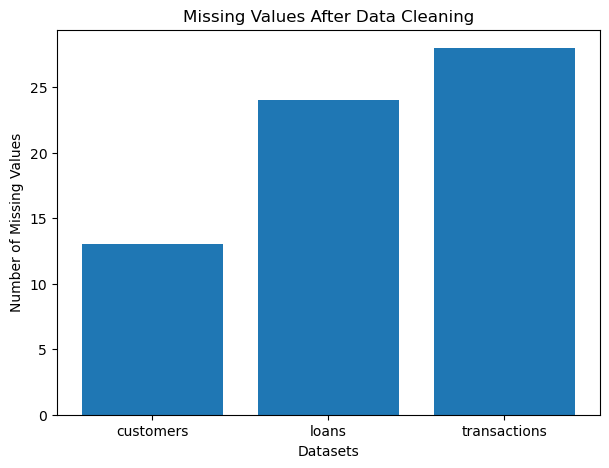

In [70]:
missing_customers = customers.isnull().sum().sum()
missing_loans = loans.isnull().sum().sum()
missing_transactions = transactions.isnull().sum().sum()
dataset=['customers','loans','transactions']
missing_values=[missing_customers,missing_loans,missing_transactions]

plt.figure(figsize=(7,5))
plt.bar(dataset,missing_values)
plt.title("Missing Values After Data Cleaning")
plt.xlabel("Datasets")
plt.ylabel("Number of Missing Values")
plt.show()

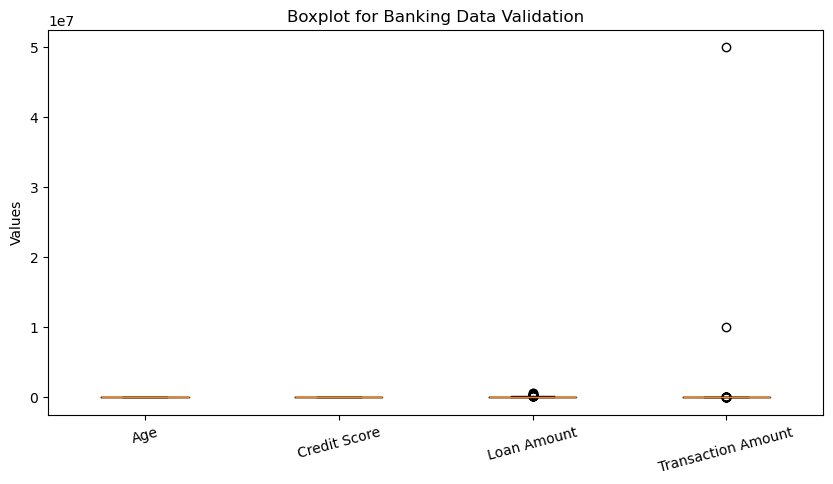

In [73]:
plt.figure(figsize=(10,5))
plt.boxplot([customers['Age'].dropna(),
             customers['Credit_Score'].dropna(),
             loans['Loan_Amount'].dropna(),
             transactions['Transaction_Amount'].dropna()],
             tick_labels=['Age','Credit Score','Loan Amount','Transaction Amount'])
plt.title("Boxplot for Banking Data Validation")
plt.ylabel("Values")
plt.xticks(rotation=15)
plt.show()

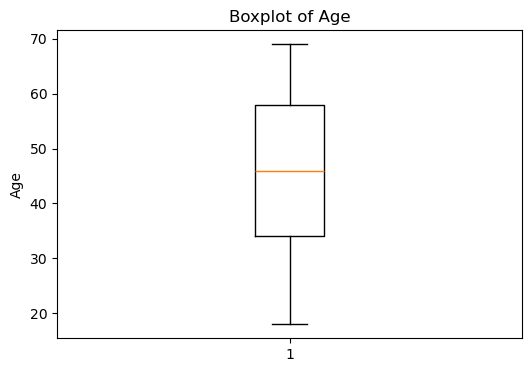

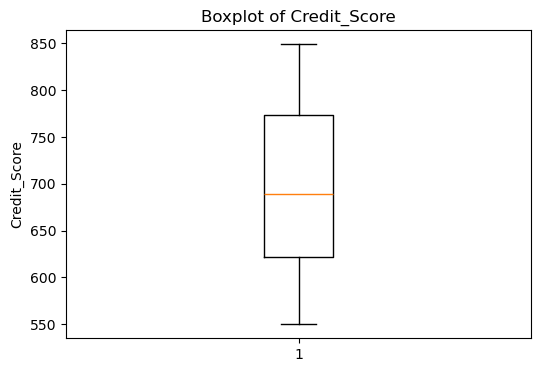

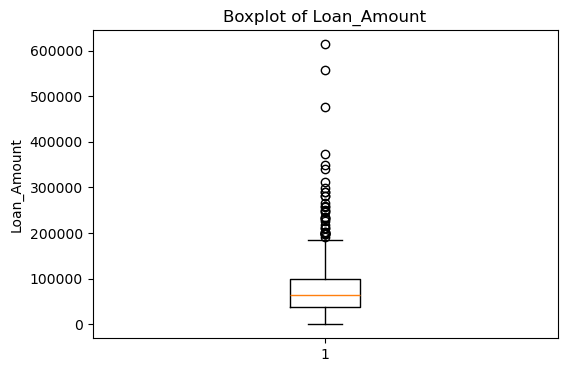

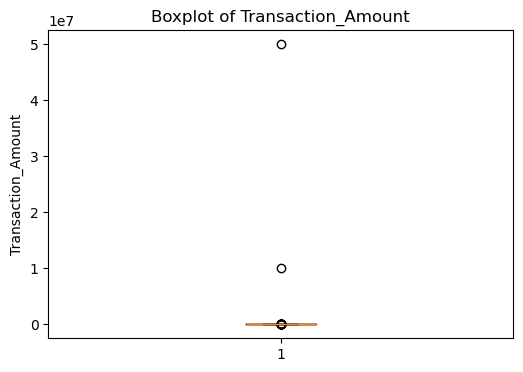

In [74]:
# Separate boxplots
columns = [
    (customers, 'Age'),
    (customers, 'Credit_Score'),
    (loans, 'Loan_Amount'),
    (transactions, 'Transaction_Amount')
]

for df, column in columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

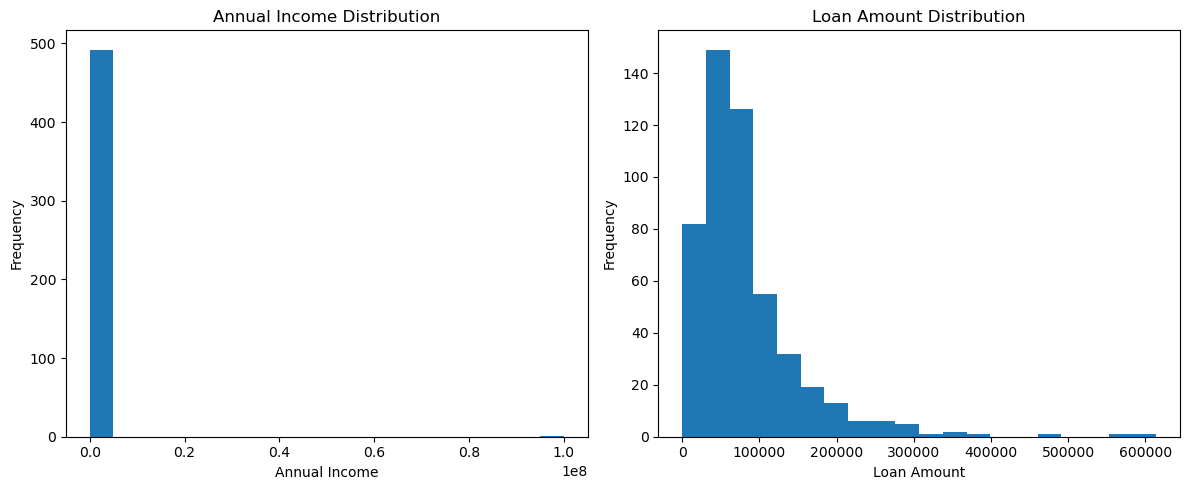

In [75]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(customers['Annual_Income'].dropna(), bins=20)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(loans['Loan_Amount'].dropna(), bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [76]:
print("Negative Loan Amounts:",
      (loans['Loan_Amount'] < 0).sum())

print("Negative Collateral Values:",
      (loans['Collateral_Value'] < 0).sum())

print("Negative Transaction Amounts:",
      (transactions['Transaction_Amount'] < 0).sum())

Negative Loan Amounts: 0
Negative Collateral Values: 0
Negative Transaction Amounts: 0


In [77]:
customers.to_csv("cleaned_customers.csv", index=False)
loans.to_csv("cleaned_loans.csv", index=False)
transactions.to_csv("cleaned_transactions.csv", index=False)

print("Cleaned datasets exported successfully.")

Cleaned datasets exported successfully.
